# Resume Classification Project

This notebook demonstrates a multi-model resume classification system that:
1. Extracts structured information from resumes (PDF/DOCX/TXT)
2. Uses spaCy for intelligent feature extraction
3. Classifies resumes into career clusters using both:
   - Bag of Words (BoW) machine learning model
   - Gemini LLM for contextual classification using spaCy feature extraction
4. Compares results from both classification methods

## Architecture
- **Extraction Layer**: spaCy + regex-based section parsing
- **ML Model**: Logistic Regression with BoW features
- **LLM Enhancement**: Google Gemini for nuanced classification

## Project Setup and Installation

In [150]:
# Install required packages
!pip install pandas numpy scikit-learn matplotlib seaborn
!pip install spacy pdfplumber python-docx PyPDF2
!pip install google-generativeai python-dotenv
!python -m spacy download en_core_web_sm

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\amtin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\amtin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\amtin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---- ----------------------------------- 1.3/12.8 MB 13.3 MB/s eta 0:00:01
     ------------------------ --------------- 7.9/12.8 MB 28.6 MB/s eta 0:00:01
     --------------------------------------- 12.8/12.8 MB 29.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\amtin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [162]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set
plt.rcParams['figure.figsize'] = (12, 6)

## Career Cluster Definitions

We've defined 13 distinct career clusters for IT professionals:

In [173]:
cluster_names = {
    0: 'Backend Development',
    1: 'Frontend Development',
    2: 'Full Stack Development',
    3: 'Data Science & AI/ML',
    4: 'Database Administration',
    5: 'DevOps & Cloud',
    6: 'Quality Assurance',
    7: 'Security',
    8: 'Systems Administration',
    9: 'Mobile Development',
    10: 'Specialized Technologies',
    11: 'Engineering Leadership',
    12: 'Content & Documentation'
}

# Display cluster definitions
print("IT Career Clusters:")
for cluster_id, cluster_name in cluster_names.items():
    print(f"  Cluster {cluster_id}: {cluster_name}")

IT Career Clusters:
  Cluster 0: Backend Development
  Cluster 1: Frontend Development
  Cluster 2: Full Stack Development
  Cluster 3: Data Science & AI/ML
  Cluster 4: Database Administration
  Cluster 5: DevOps & Cloud
  Cluster 6: Quality Assurance
  Cluster 7: Security
  Cluster 8: Systems Administration
  Cluster 9: Mobile Development
  Cluster 10: Specialized Technologies
  Cluster 11: Engineering Leadership
  Cluster 12: Content & Documentation


## Data Loading and Exploration

Load the comparison results from both classification models.

In [183]:
bow_results = pd.read_json('../script/bow_results.json')
comparison_summary = pd.read_csv('../script/comparison_summary.csv')
comparison_details = pd.read_json('../script/comparison_details.json')
print(f"Total resumes analyzed: {len(bow_results)}")
print(f"\nDataset preview:")
comparison_summary.head()

Total resumes analyzed: 11

Dataset preview:


,file_name,bow_top1,spacy_top1,top1_match,top3_overlap
0,aws.txt,Backend Development,Full Stack Development,False,0
1,Bickford-Resume.txt,Data Science & AI/ML,Data Science & AI/ML,True,2
2,Brown-Resume.txt,Backend Development,Full Stack Development,False,1
3,Brown-v2-Resume.txt,Data Science & AI/ML,Full Stack Development,False,2
4,database-admin.txt,Database Administration,Database Administration,True,2


## Model Performance Analysis

### 1. Top-1 Agreement Rate

How often do both models agree on the primary cluster?

Top-1 Agreement Rate: 27.3%
Matching predictions: 3 / 11


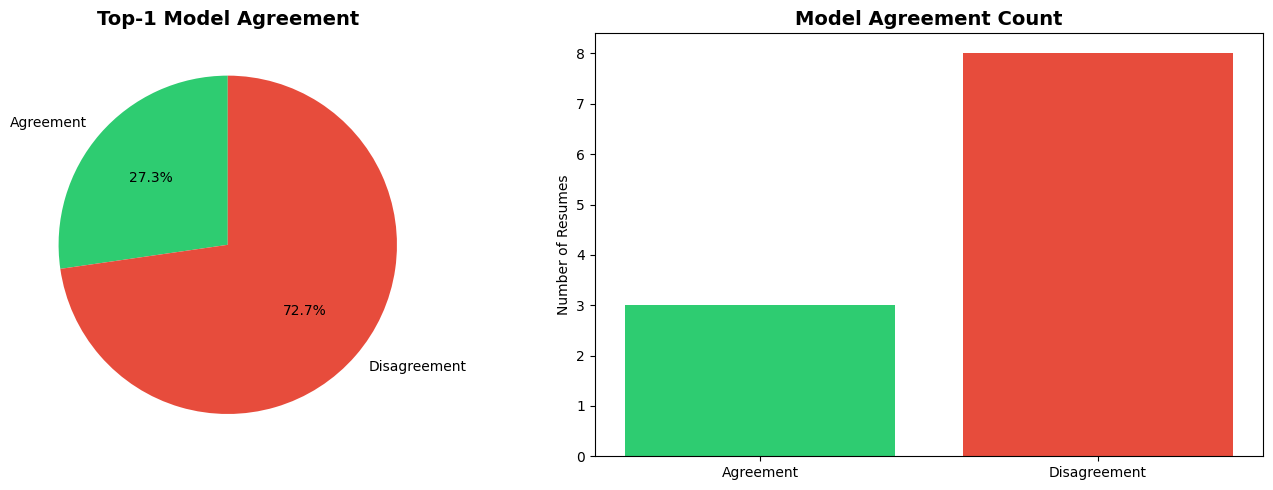

In [192]:
# Calculate top-1 agreement
top1_matches = comparison_summary['top1_match'].sum()
total_resumes = len(comparison_summary)
agreement_rate = top1_matches / total_resumes

print(f"Top-1 Agreement Rate: {agreement_rate:.1%}")
print(f"Matching predictions: {top1_matches} / {total_resumes}")

# Visualize agreement
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
ax[0].pie([top1_matches, total_resumes - top1_matches], labels=['Agreement', 'Disagreement'], autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
ax[0].set_title('Top-1 Model Agreement', fontsize=14, fontweight='bold')

# Bar chart
ax[1].bar(['Agreement', 'Disagreement'], [top1_matches, total_resumes - top1_matches], color=['#2ecc71', '#e74c3c'])
ax[1].set_ylabel('Number of Resumes')
ax[1].set_title('Model Agreement Count', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 2. Top-3 Overlap Analysis

How many clusters appear in both models' top-3 predictions?

Average Top-3 Overlap: 1.36 clusters
Overlap Distribution:
top3_overlap
0    2
1    4
2    4
3    1
Name: count, dtype: int64


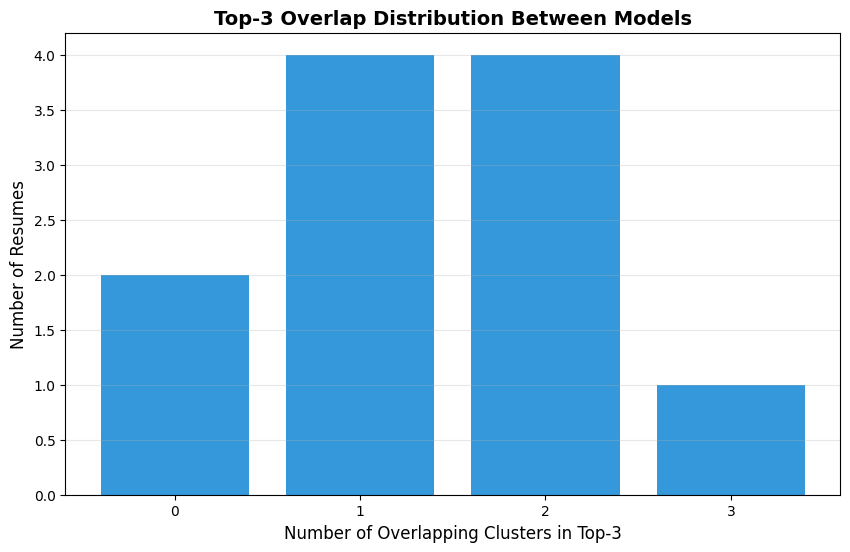

In [200]:
# Calculate average top-3 overlap
avg_overlap = comparison_summary['top3_overlap'].mean()

print(f"Average Top-3 Overlap: {avg_overlap:.2f} clusters")
print(f"Overlap Distribution:")
print(comparison_summary['top3_overlap'].value_counts().sort_index())

# Visualize overlap distribution
plt.figure(figsize=(10, 6))
overlap_counts = comparison_summary['top3_overlap'].value_counts().sort_index()
plt.bar(overlap_counts.index, overlap_counts.values, color='#3498db')
plt.xlabel('Number of Overlapping Clusters in Top-3', fontsize=12)
plt.ylabel('Number of Resumes', fontsize=12)
plt.title('Top-3 Overlap Distribution Between Models', fontsize=14, fontweight='bold')
plt.xticks(range(4))
plt.grid(axis='y', alpha=0.3)
plt.show()

### Bag of Words Confidence Analysis

BoW Confidence Statistics:
count    11.000000
mean      0.622070
std       0.249992
min       0.325221
25%       0.419655
50%       0.567090
75%       0.826913
max       0.999984
Name: bow_confidence, dtype: float64


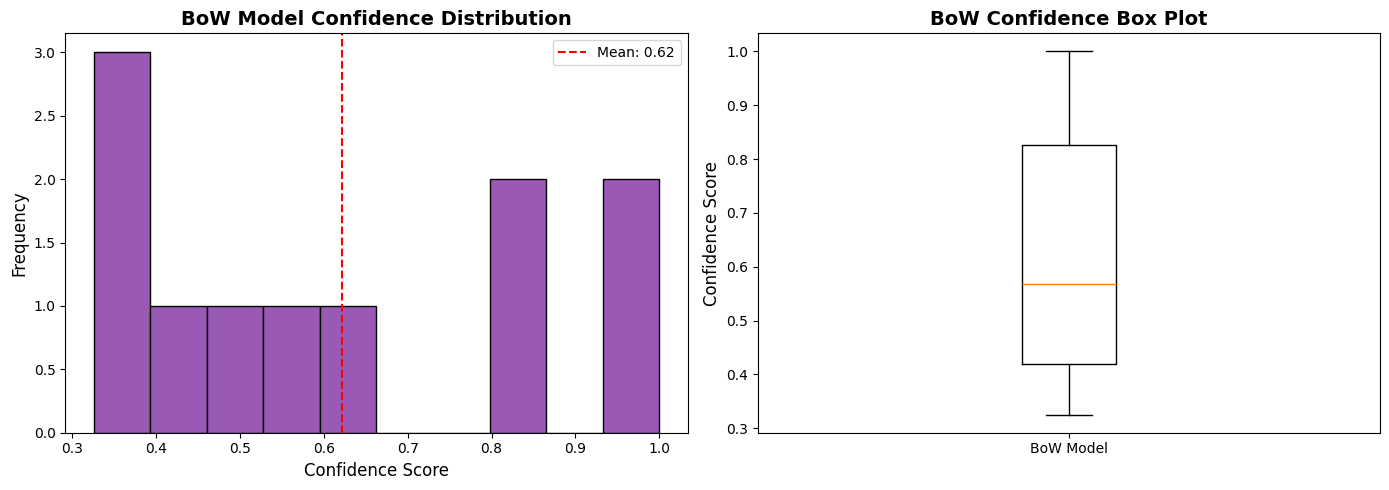

In [207]:
# Analyze BoW confidence scores
print("BoW Confidence Statistics:")
print(bow_results['bow_confidence'].describe())

# Visualize confidence distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax[0].hist(bow_results['bow_confidence'], bins=10, color='#9b59b6', edgecolor='black')
ax[0].set_xlabel('Confidence Score', fontsize=12)
ax[0].set_ylabel('Frequency', fontsize=12)
ax[0].set_title('BoW Model Confidence Distribution', fontsize=14, fontweight='bold')
ax[0].axvline(bow_results['bow_confidence'].mean(), color='red', linestyle='--', label=f'Mean: {bow_results["bow_confidence"].mean():.2f}')
ax[0].legend()

# Box plot
ax[1].boxplot(bow_results['bow_confidence'], vert=True)
ax[1].set_ylabel('Confidence Score', fontsize=12)
ax[1].set_title('BoW Confidence Box Plot', fontsize=14, fontweight='bold')
ax[1].set_xticklabels(['BoW Model'])

plt.tight_layout()
plt.show()

## Cluster-Level Analysis

### Predictions by Cluster

Cluster Predictions by Model:
                         BoW Model  SpaCy/Gemini Model
Backend Development              4                   1
Data Science & AI/ML             5                   2
Database Administration          1                   1
Full Stack Development           0                   7
Quality Assurance                1                   0


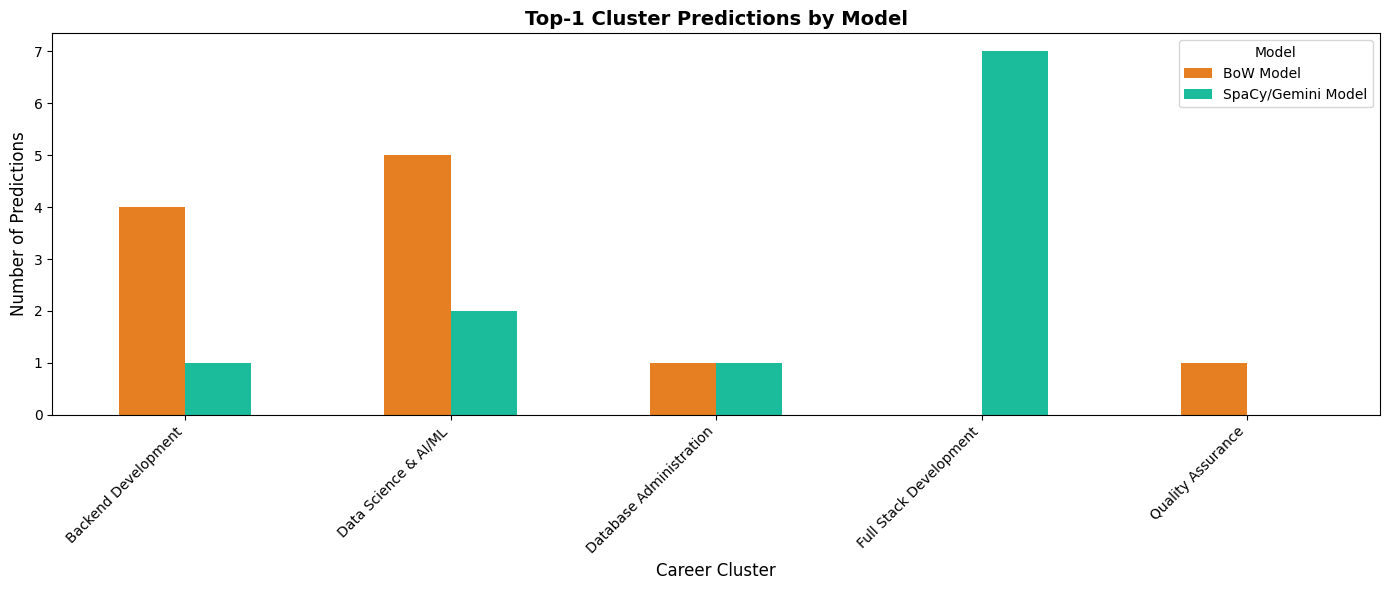

In [213]:
# Count predictions by cluster for each model
bow_clusters = comparison_summary['bow_top1'].value_counts()
spacy_clusters = comparison_summary['spacy_top1'].value_counts()

# Combine into DataFrame
cluster_comparison = pd.DataFrame({'BoW Model': bow_clusters, 'SpaCy/Gemini Model': spacy_clusters}).fillna(0).astype(int)

print("Cluster Predictions by Model:")
print(cluster_comparison.sort_index())

# Visualize
cluster_comparison.plot(kind='bar', figsize=(14, 6), color=['#e67e22', '#1abc9c'])
plt.xlabel('Career Cluster', fontsize=12)
plt.ylabel('Number of Predictions', fontsize=12)
plt.title('Top-1 Cluster Predictions by Model', fontsize=14, fontweight='bold')
plt.legend(title='Model')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


## Case Studies: Individual Resume Analysis

Let's see specific examples where models agree and disagree.

In [218]:
# Cases where models AGREE
print("=" * 70)
print("CASES WHERE MODELS AGREE (Top-1)")
print("=" * 70)

agreed_cases = comparison_summary[comparison_summary['top1_match'] == True]
for idx, row in agreed_cases.iterrows():
    print(f"\n{row['file_name']}")
    print(f"  Both models predict: {row['bow_top1']}")
    print(f"  Top-3 overlap: {row['top3_overlap']} clusters")

# Cases where models DISAGREE
print("=" * 70)
print("CASES WHERE MODELS DISAGREE (Top-1)")
print("=" * 70)

disagreed_cases = comparison_summary[comparison_summary['top1_match'] == False]
for idx, row in disagreed_cases.iterrows():
    print(f"\n{row['file_name']}")
    print(f"  BoW Model:          {row['bow_top1']}")
    print(f"  SpaCy/Gemini Model: {row['spacy_top1']}")
    print(f"  Top-3 overlap: {row['top3_overlap']} clusters")

CASES WHERE MODELS AGREE (Top-1)

Bickford-Resume.txt
  Both models predict: Data Science & AI/ML
  Top-3 overlap: 2 clusters

database-admin.txt
  Both models predict: Database Administration
  Top-3 overlap: 2 clusters

Fantigrossi-CV.txt
  Both models predict: Data Science & AI/ML
  Top-3 overlap: 1 clusters
CASES WHERE MODELS DISAGREE (Top-1)

aws.txt
  BoW Model:          Backend Development
  SpaCy/Gemini Model: Full Stack Development
  Top-3 overlap: 0 clusters

Brown-Resume.txt
  BoW Model:          Backend Development
  SpaCy/Gemini Model: Full Stack Development
  Top-3 overlap: 1 clusters

Brown-v2-Resume.txt
  BoW Model:          Data Science & AI/ML
  SpaCy/Gemini Model: Full Stack Development
  Top-3 overlap: 2 clusters

Eric Ocke Resume.txt
  BoW Model:          Backend Development
  SpaCy/Gemini Model: Full Stack Development
  Top-3 overlap: 3 clusters

old-example.txt
  BoW Model:          Data Science & AI/ML
  SpaCy/Gemini Model: Full Stack Development
  Top-3 overlap

### Detailed Example: Top-3 Predictions

In [222]:
# Show detailed top-3 predictions for a specific resume
print("Available resumes:")
for idx, filename in enumerate(comparison_details['file_name']):
    print(f"  {idx}: {filename}")

# Change this index to analyze different resumes
selected_idx = 3 
example_file = comparison_details.iloc[selected_idx]

print(f"Detailed Analysis: {example_file['file_name']}")
print("=" * 70)

print("\nBoW Model Top-3:")
for i, cluster in enumerate(example_file['bow_top3'], 1):
    print(f"  {i}. {cluster}")

print("\nSpaCy/Gemini Model Top-3:")
for i, cluster in enumerate(example_file['spacy_top3'], 1):
    print(f"  {i}. {cluster}")

# Load spaCy results to get reasoning for Top-1 cluster
spacy_results_path = Path('../models/spacy_data/classified_resumes.json')
if spacy_results_path.exists():
    with open(spacy_results_path, encoding='utf-8') as f:
        spacy_results = json.load(f)
    
    # Find the matching file in spacy results
    spacy_result = next((r for r in spacy_results if r['file_name'] == example_file['file_name']), None)
    
    if spacy_result and spacy_result['classification'].get('success'):
        print("\nGemini Reasoning for Top-1 Cluster:")
        reasoning = spacy_result['classification'].get('reasoning', 'No reasoning provided')
        # Wrap text for better readability
        import textwrap
        wrapped_reasoning = textwrap.fill(reasoning, width=70)
        print(f"  {wrapped_reasoning}")
    else:
        print("\nGemini Reasoning: Not available (classification failed or not found)")
else:
    print("\nGemini Reasoning: SpaCy results file not found")

print(f"\nTop-1 Match: {example_file['top1_match']}")
print(f"Top-3 Overlap: {example_file['top3_overlap']} clusters")

Available resumes:
  0: aws.txt
  1: Bickford-Resume.txt
  2: Brown-Resume.txt
  3: Brown-v2-Resume.txt
  4: database-admin.txt
  5: Eric Ocke Resume.txt
  6: Fantigrossi-CV.txt
  7: old-example.txt
  8: old-example2.txt
  9: Thiele-Resume.txt
  10: Tintera-Resume.txt
Detailed Analysis: Brown-v2-Resume.txt

BoW Model Top-3:
  1. Data Science & AI/ML
  2. Frontend Development
  3. Backend Development

SpaCy/Gemini Model Top-3:
  1. Full Stack Development
  2. Backend Development
  3. Frontend Development

Gemini Reasoning for Top-1 Cluster:
  This resume is classified as Full Stack Development due to a
comprehensive set of skills covering both frontend and backend
technologies. For frontend, the candidate lists `React.js/Next.js`,
`HTML/CSS`, `Javascript`, and `Typescript`. For backend, key skills
include `Java`, `Python`, `C`, `C++`, `SQL`, `MySQL`, and `restful`
(implying API development). The inclusion of `Docker` further supports
full-stack development by indicating knowledge of con

## Confidence Score Analysis

Compare confidence when models agree vs disagree

BoW Confidence When Models:
  Agree:    Mean = 0.770, Std = 0.385
  Disagree: Mean = 0.567, Std = 0.185


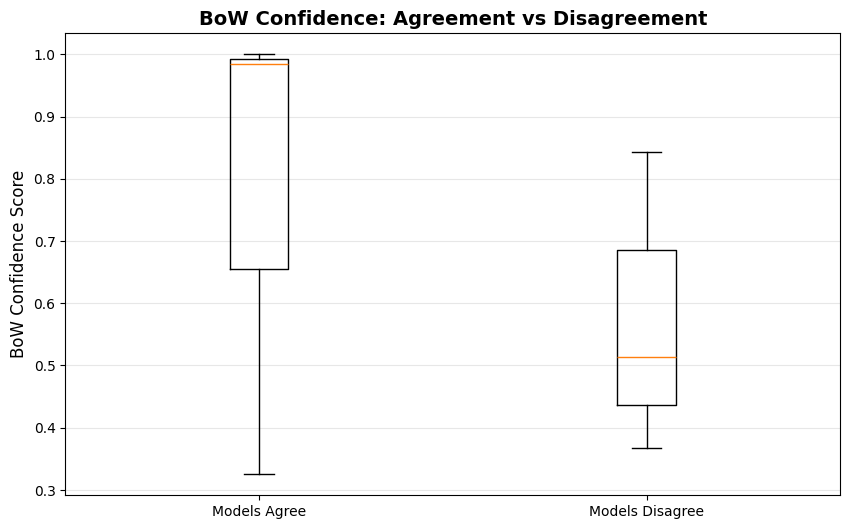

In [225]:
# Merge confidence data
merged = comparison_summary.merge(bow_results[['file_name', 'bow_confidence']], on='file_name')

# Compare confidence when models agree vs disagree
agree_conf = merged[merged['top1_match'] == True]['bow_confidence']
disagree_conf = merged[merged['top1_match'] == False]['bow_confidence']
print("BoW Confidence When Models:")
print(f"  Agree:    Mean = {agree_conf.mean():.3f}, Std = {agree_conf.std():.3f}")
print(f"  Disagree: Mean = {disagree_conf.mean():.3f}, Std = {disagree_conf.std():.3f}")


# Visualize
plt.figure(figsize=(10, 6))
plt.boxplot([agree_conf, disagree_conf], labels=['Models Agree', 'Models Disagree'])
plt.ylabel('BoW Confidence Score', fontsize=12)
plt.title('BoW Confidence: Agreement vs Disagreement', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()

## Summary and Insights

### Key Findings

In [227]:
print("=" * 70)
print("RESUME CLASSIFICATION PROJECT SUMMARY")
print("=" * 70)

print(f"\nDataset Statistics:")
print(f"   Total resumes analyzed: {len(bow_results)}")
print(f"   Career clusters: {len(cluster_names)}")

print("\nModel Agreement:")
print(f"   Top-1 agreement rate: {agreement_rate:.1%}")
print(f"   Average top-3 overlap: {avg_overlap:.2f} clusters")

print(f"\nBoW Model Performance:")
print(f"   Mean confidence: {bow_results['bow_confidence'].mean():.3f}")
print(f"   Median confidence: {bow_results['bow_confidence'].median():.3f}")
print(f"   Min confidence: {bow_results['bow_confidence'].min():.3f}")
print(f"   Max confidence: {bow_results['bow_confidence'].max():.3f}")

print(f"\nTop Predicted Clusters:")
print("   BoW Model:")
for cluster, count in bow_clusters.head(3).items():
    print(f"      - {cluster}: {count} resumes")
print("   SpaCy/Gemini Model:")
for cluster, count in spacy_clusters.head(3).items():
    print(f"      - {cluster}: {count} resumes")
print("\n" + "=" * 70)


RESUME CLASSIFICATION PROJECT SUMMARY

Dataset Statistics:
   Total resumes analyzed: 11
   Career clusters: 13

Model Agreement:
   Top-1 agreement rate: 27.3%
   Average top-3 overlap: 1.36 clusters

BoW Model Performance:
   Mean confidence: 0.622
   Median confidence: 0.567
   Min confidence: 0.325
   Max confidence: 1.000

Top Predicted Clusters:
   BoW Model:
      - Data Science & AI/ML: 5 resumes
      - Backend Development: 4 resumes
      - Database Administration: 1 resumes
   SpaCy/Gemini Model:
      - Full Stack Development: 7 resumes
      - Data Science & AI/ML: 2 resumes
      - Database Administration: 1 resumes



## Model Comparison Insights

### Strengths of Each Approach:

**Bag of Words Model:**
    - Fast and efficient for large-scale classification
    - Provides probability distributions across all clusters
    - Good for keyword-heavy resumes
    - Transparent feature importance

**SpaCy/Gemini Model:**
    - Better contextual understanding
    - Handles nuanced skills and experience descriptions
    - More flexible with resume formats
    - Provides reasoning for classifications

### When Models Agree:
    - High confidence in classification
    - Clear indicators of specific career path
    - Strong keyword presence

### When Models Disagree:
    - Potential for multi-disciplinary background
    - Transitioning between career paths
    - May benefit from human review 

## Future Improvements
1. Combine spaCy feature vectors with Bag of Words vectors for more nuanced classification
2. Design user interface with file uploading capabilities